In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [28]:
train_path = "server_runs/runs/train/train_07_10_2025__15_10_00/iql_train_output_07_10_2025__15_10_00.csv"
results = pd.read_csv(train_path)
results.head()

,Episode,Tick,Avg reward X episode,random-walk,move-toward-chemical-0,move-and-drop-chemical-1,(learner 0)-random-walk,(learner 0)-move-toward-chemical-0,(learner 0)-move-and-drop-chemical-1,(learner 1)-random-walk,...,(learner 37)-random-walk,(learner 37)-move-toward-chemical-0,(learner 37)-move-and-drop-chemical-1,(learner 38)-random-walk,(learner 38)-move-toward-chemical-0,(learner 38)-move-and-drop-chemical-1,(learner 39)-random-walk,(learner 39)-move-toward-chemical-0,(learner 39)-move-and-drop-chemical-1,Epsilon
0,1,1000,-0.0897,13293,13407,13260,322,346,331,331,...,340,324,335,342,329,328,320,343,336,0.9950
1,2,1000,-0.0885,13290,13384,13286,306,349,344,338,...,321,332,346,327,321,351,303,350,346,0.9900
2,3,1000,-0.0875,13292,13272,13396,375,311,313,349,...,330,343,326,332,318,349,339,338,322,0.9851
3,4,1000,-0.0910,13323,13363,13274,326,345,328,322,...,312,361,326,332,308,359,316,356,327,0.9801
4,5,1000,-0.0894,13174,13472,13314,314,332,353,309,...,303,359,337,349,331,319,346,312,341,0.9752


# Reward 

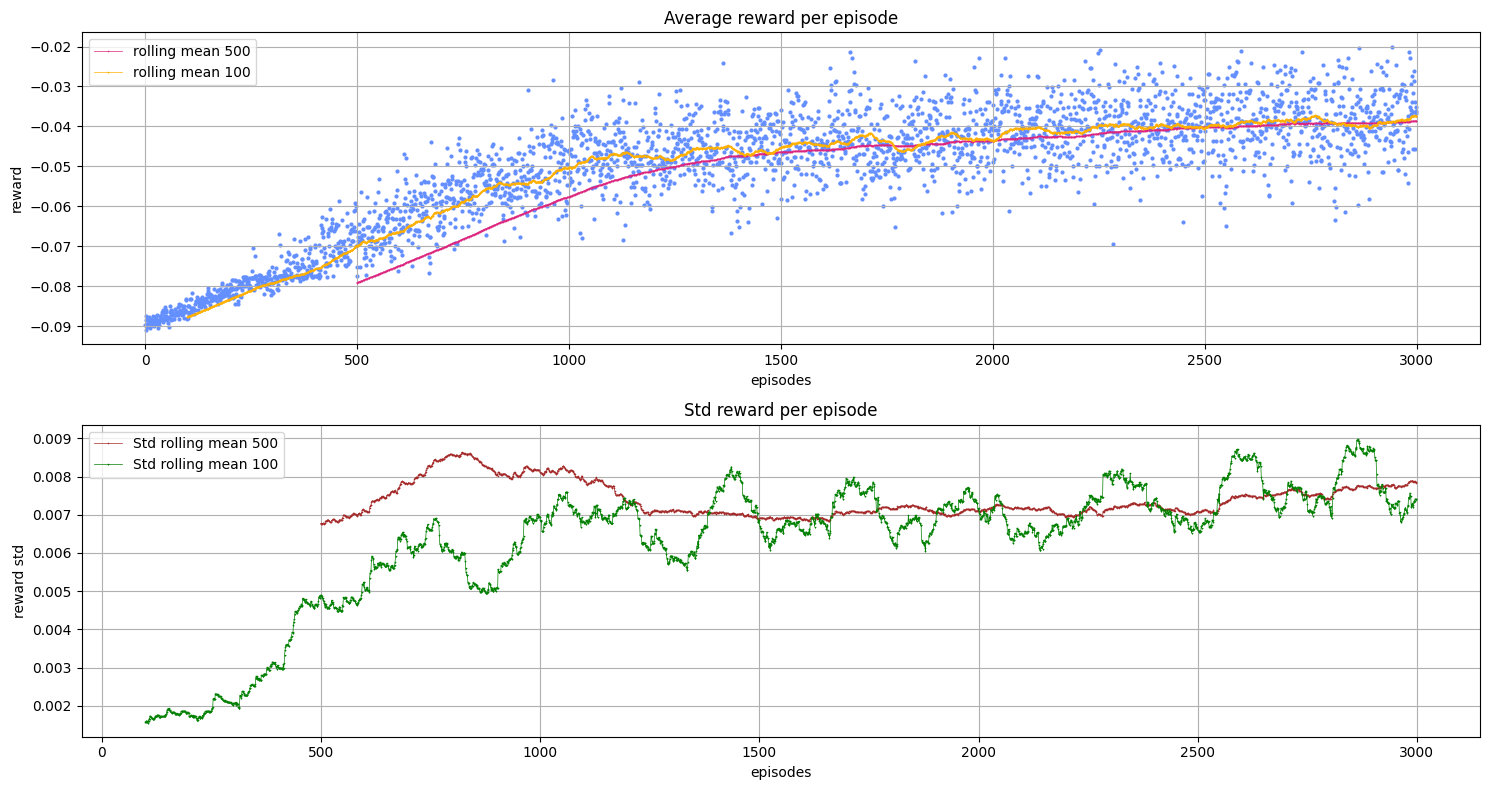

In [29]:
# DOC plot average reward over time
#fig = plt.figure(figsize=(10, 4), dpi=200)
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(15, 8))  # 1 riga, 2 colonne
ax0.grid()
ax0.set_title(f"Average reward per episode")
ax0.set_ylabel(f"reward")
ax0.set_xlabel(f"episodes")
ax0.scatter(results.index, results["Avg reward X episode"], s=4, linewidth=1.0, color='#648FFF')
ax0.plot(results.index, results["Avg reward X episode"].rolling(window=500).mean(), label="rolling mean 500", marker='x',
         markersize=.5, linewidth=.5, color='#DC267F')
ax0.plot(results.index, results["Avg reward X episode"].rolling(100).mean(), label="rolling mean 100", marker='^',
         markersize=.5, linewidth=.5, color='#FFB000')
ax0.legend()

ax1.grid()
ax1.set_title(f"Std reward per episode")
ax1.set_ylabel(f"reward std")
ax1.set_xlabel(f"episodes")
#plt.scatter(results.index, results["Avg reward X episode"], s=4, linewidth=1.0, color='#648FFF')
ax1.plot(results.index, results["Avg reward X episode"].rolling(window=500).std(), label="Std rolling mean 500", marker='x',
         markersize=.5, linewidth=.5, color='brown')
ax1.plot(results.index, results["Avg reward X episode"].rolling(100).std(), label="Std rolling mean 100", marker='^',
         markersize=.5, linewidth=.5, color='green')
ax1.legend()

fig.tight_layout()
#plt.savefig("Cluster_avg_reward")
plt.show()

# Ticks

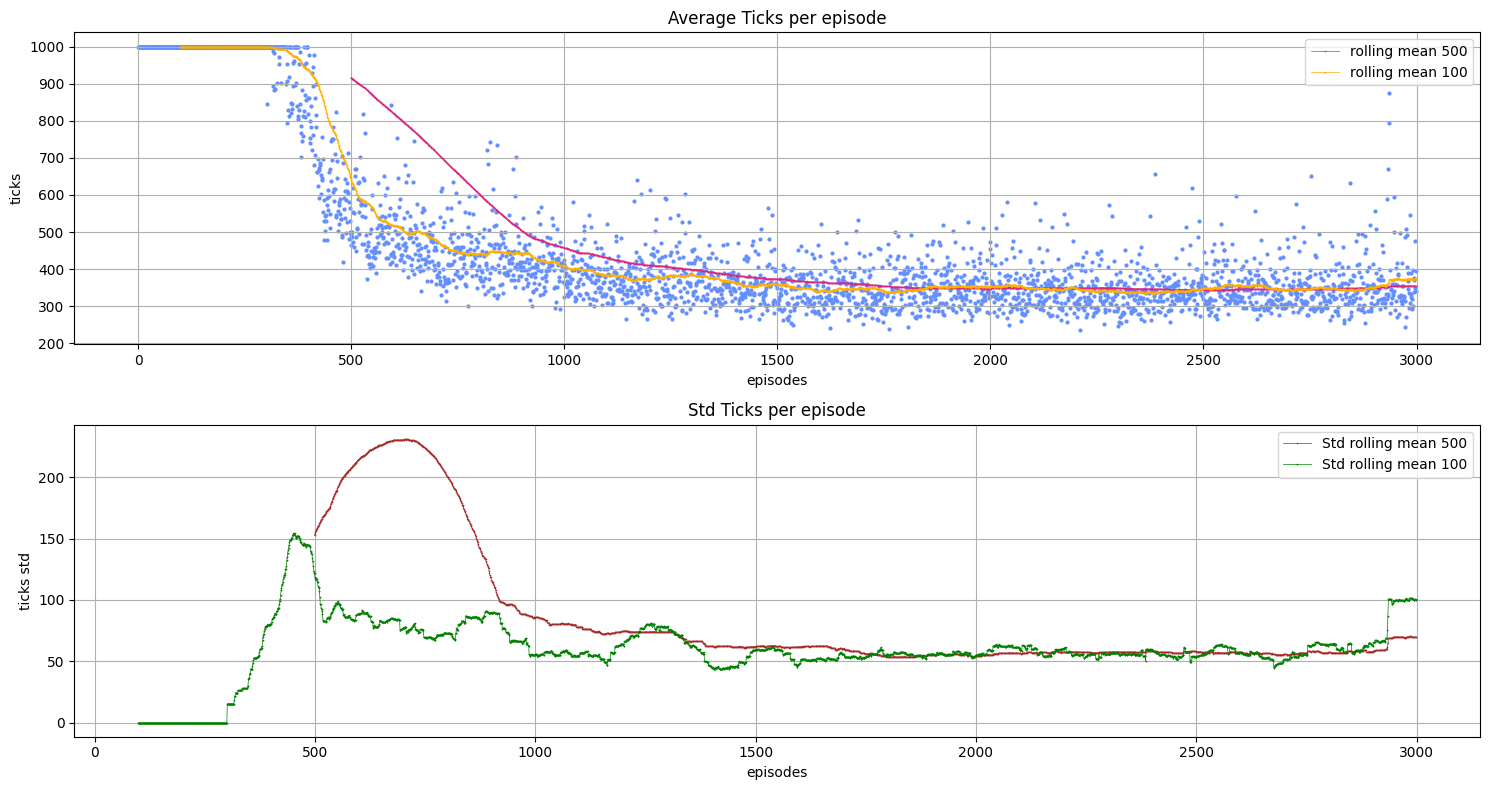

In [25]:
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(15, 8))  # 1 riga, 2 colonne
ax0.grid()
ax0.set_title(f"Average Ticks per episode")
ax0.set_ylabel(f"ticks")
ax0.set_xlabel(f"episodes")
ax0.scatter(results.index, results["Tick"], s=4, linewidth=1.0, color='#648FFF')
ax0.plot(results.index, results["Tick"].rolling(window=500).mean(), label="rolling mean 500", marker='x',
         markersize=.5, linewidth=.5, color='#DC267F')
ax0.plot(results.index, results["Tick"].rolling(100).mean(), label="rolling mean 100", marker='^',
         markersize=.5, linewidth=.5, color='#FFB000')
ax0.legend()

ax1.grid()
ax1.set_title(f"Std Ticks per episode")
ax1.set_ylabel(f"ticks std")
ax1.set_xlabel(f"episodes")
#plt.scatter(results.index, results["Avg reward X episode"], s=4, linewidth=1.0, color='#648FFF')
ax1.plot(results.index, results["Tick"].rolling(window=500).std(), label="Std rolling mean 500", marker='x',
         markersize=.5, linewidth=.5, color='brown')
ax1.plot(results.index, results["Tick"].rolling(100).std(), label="Std rolling mean 100", marker='^',
         markersize=.5, linewidth=.5, color='green')
ax1.legend()

fig.tight_layout()
#plt.savefig("Cluster_avg_reward")
plt.show()

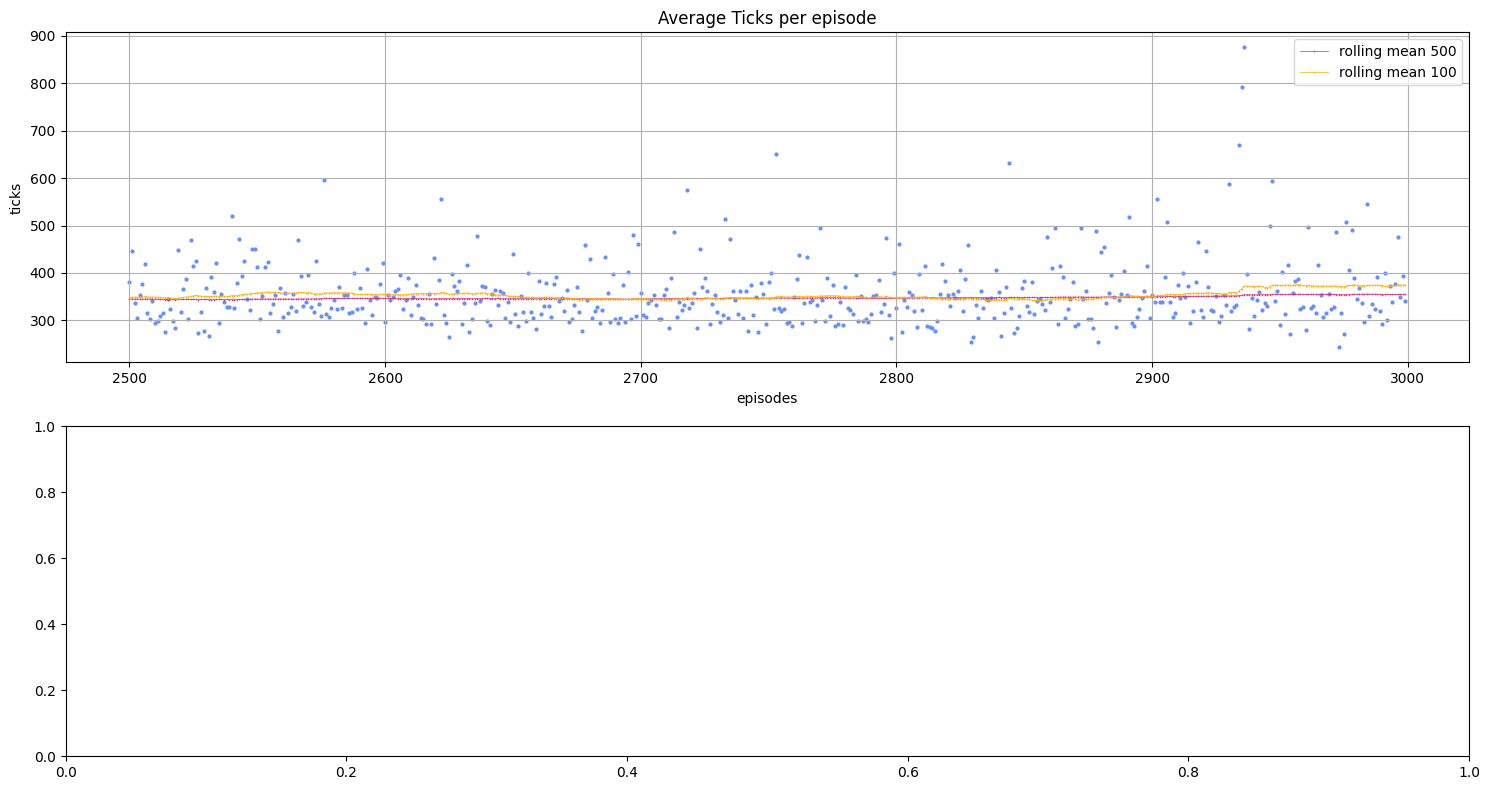

In [26]:
x = [i for i in range(2500, 3000)]
y1 = results["Tick"].rolling(window=500).mean()
y2 = results["Tick"].rolling(100).mean()
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(15, 8))  # 1 riga, 2 colonne
ax0.grid()
ax0.set_title(f"Average Ticks per episode")
ax0.set_ylabel(f"ticks")
ax0.set_xlabel(f"episodes")
ax0.scatter(x, results["Tick"][-500:], s=4, linewidth=1.0, color='#648FFF')
ax0.plot(x, y1[-500:], label="rolling mean 500", marker='x',
         markersize=.5, linewidth=.5, color='#DC267F')
ax0.plot(x, y2[-500:], label="rolling mean 100", marker='^',
         markersize=.5, linewidth=.5, color='#FFB000')
ax0.legend()

#ax1.grid()
#ax1.set_title(f"Std Ticks per episode")
#ax1.set_ylabel(f"ticks std")
#ax1.set_xlabel(f"episodes")
##plt.scatter(results.index, results["Avg reward X episode"], s=4, linewidth=1.0, color='#648FFF')
#ax1.plot(x, y1[-500:], label="Std rolling mean 500", marker='x',
#         markersize=.5, linewidth=.5, color='brown')
#ax1.plot(x, results["Tick"][-500:].rolling(100).std(), label="Std rolling mean 100", marker='^',
#         markersize=.5, linewidth=.5, color='green')
#ax1.legend()

fig.tight_layout()
#plt.savefig("Cluster_avg_reward")
plt.show()

# Actions

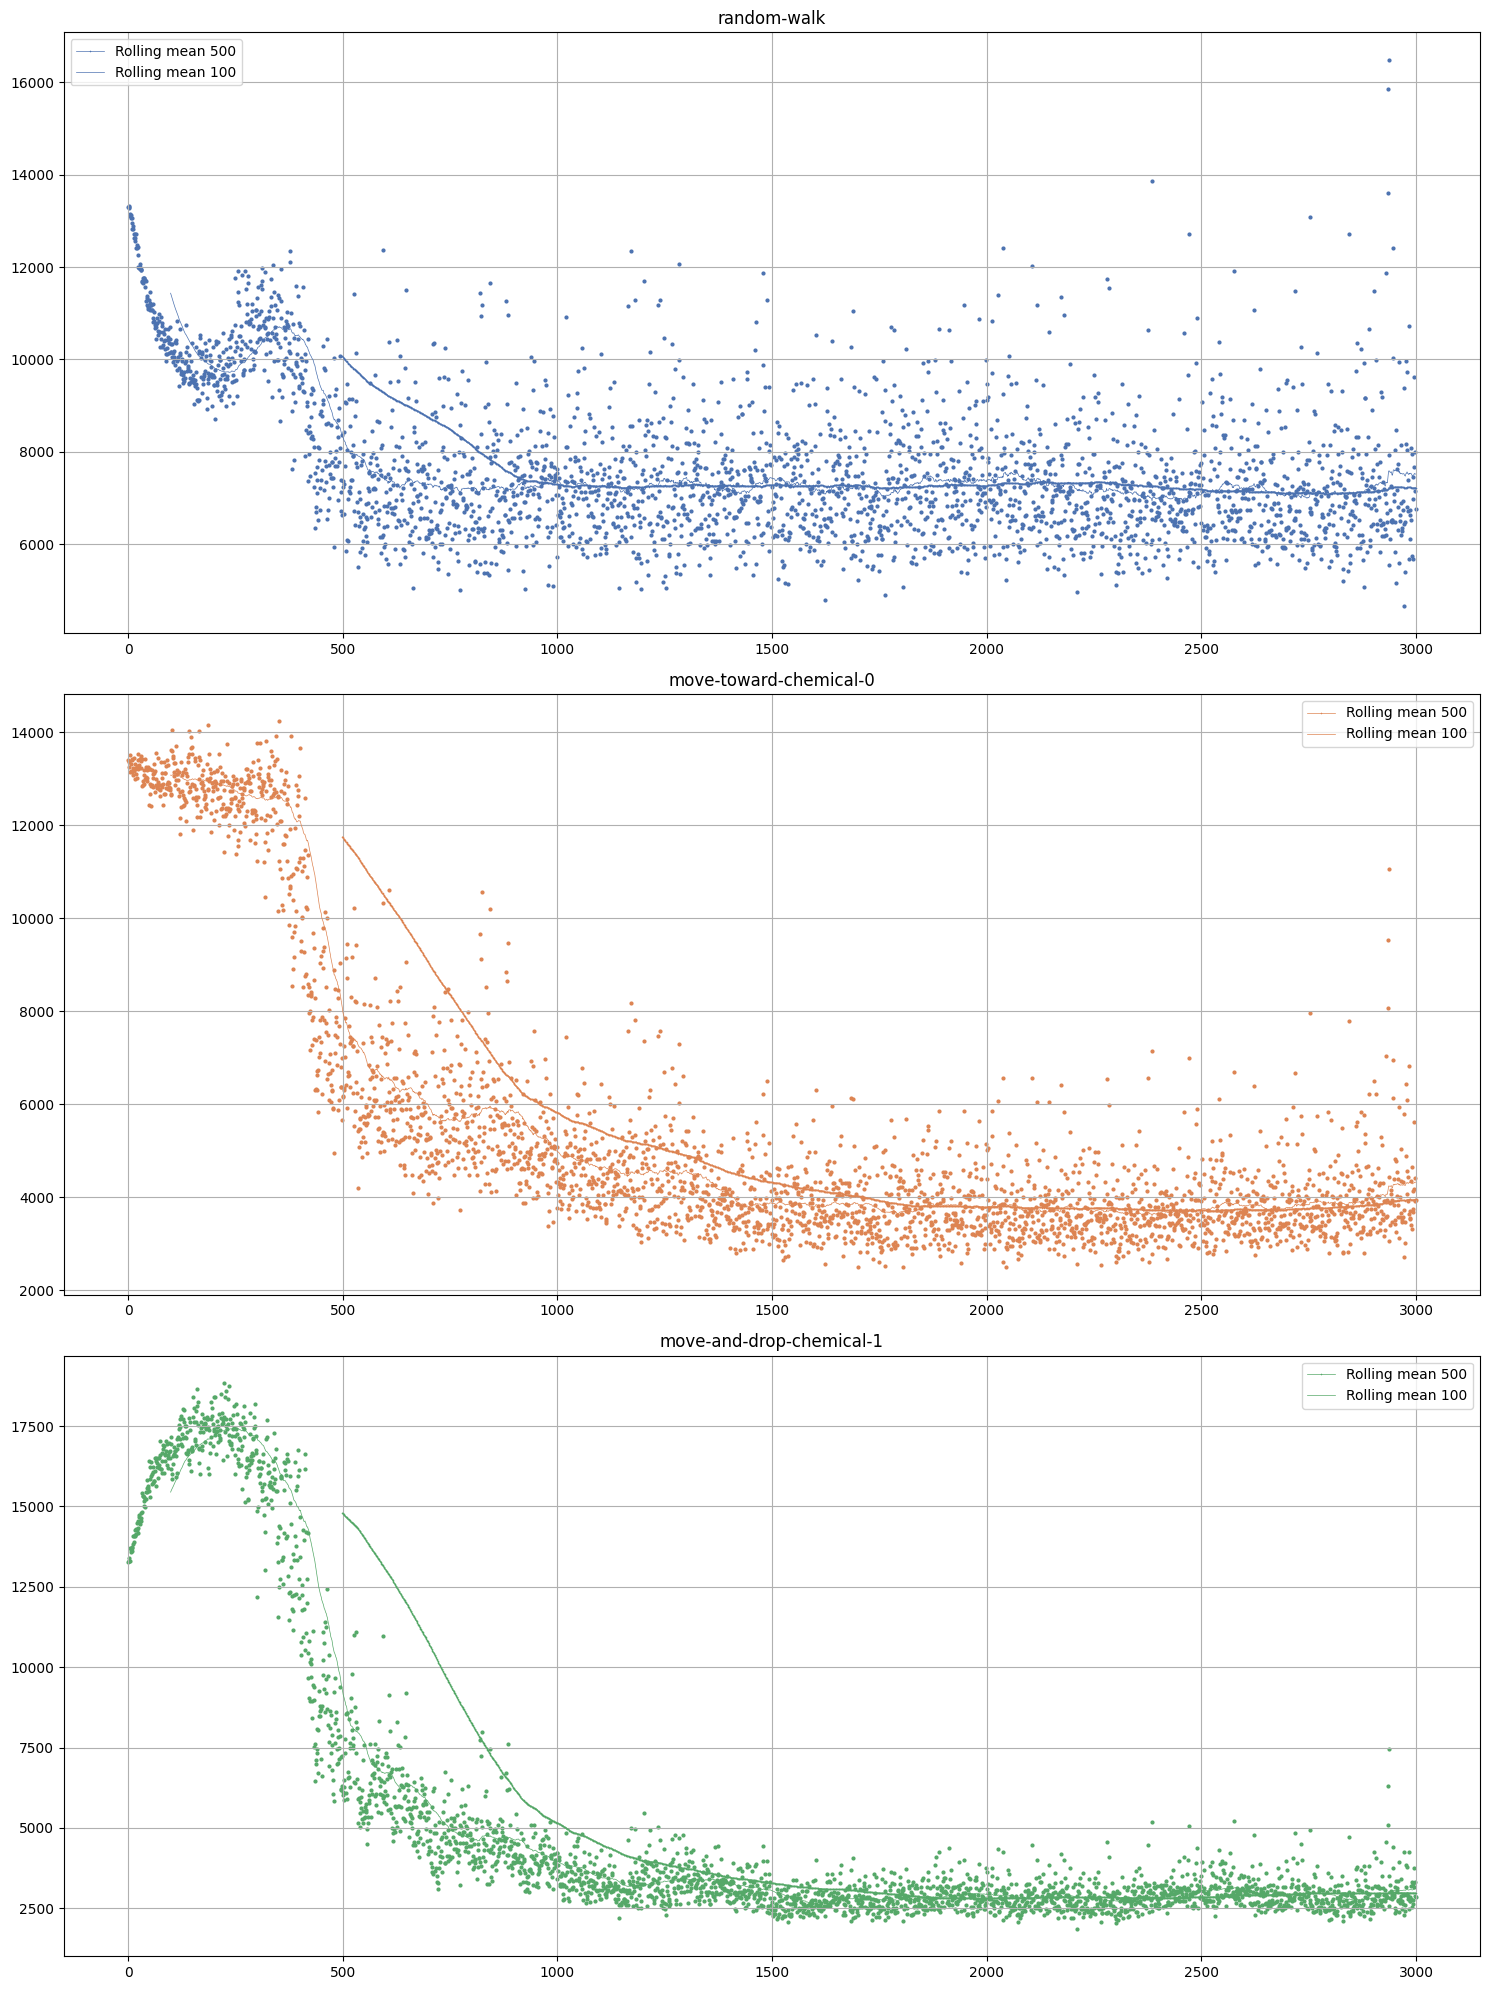

In [27]:
colors = ('#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#64B5CD', '#FFB000')
num_actions = 3
#num_actions = 4
#num_actions = 5
#num_actions = 6
#num_actions = 7
#fig, axs = plt.subplots(num_actions, 1, figsize=(15, 15))  # 1 riga, 2 colonne
fig, axs = plt.subplots(num_actions, 1, figsize=(15, 20))  # 1 riga, 2 colonne
for i, ax in enumerate(axs):
    idx = i + 3
    #idx = i + 7
    ax.grid()
    ax.scatter(results.index, results[results.columns[idx]], s=4, linewidth=1.0, color=colors[i])
    ax.plot(results.index, results[results.columns[idx]].rolling(window=500).mean(), label="Rolling mean 500", marker='x',
            markersize=.5, linewidth=.5, color=colors[i])
    ax.plot(results.index, results[results.columns[idx]].rolling(window=100).mean(), label="Rolling mean 100",
            markersize=.5, linewidth=.5, color=colors[i])
    ax.set_title(results.columns[idx])
    ax.legend()
fig.tight_layout()
#plt.savefig("Cluster_avg_actions")
plt.show()

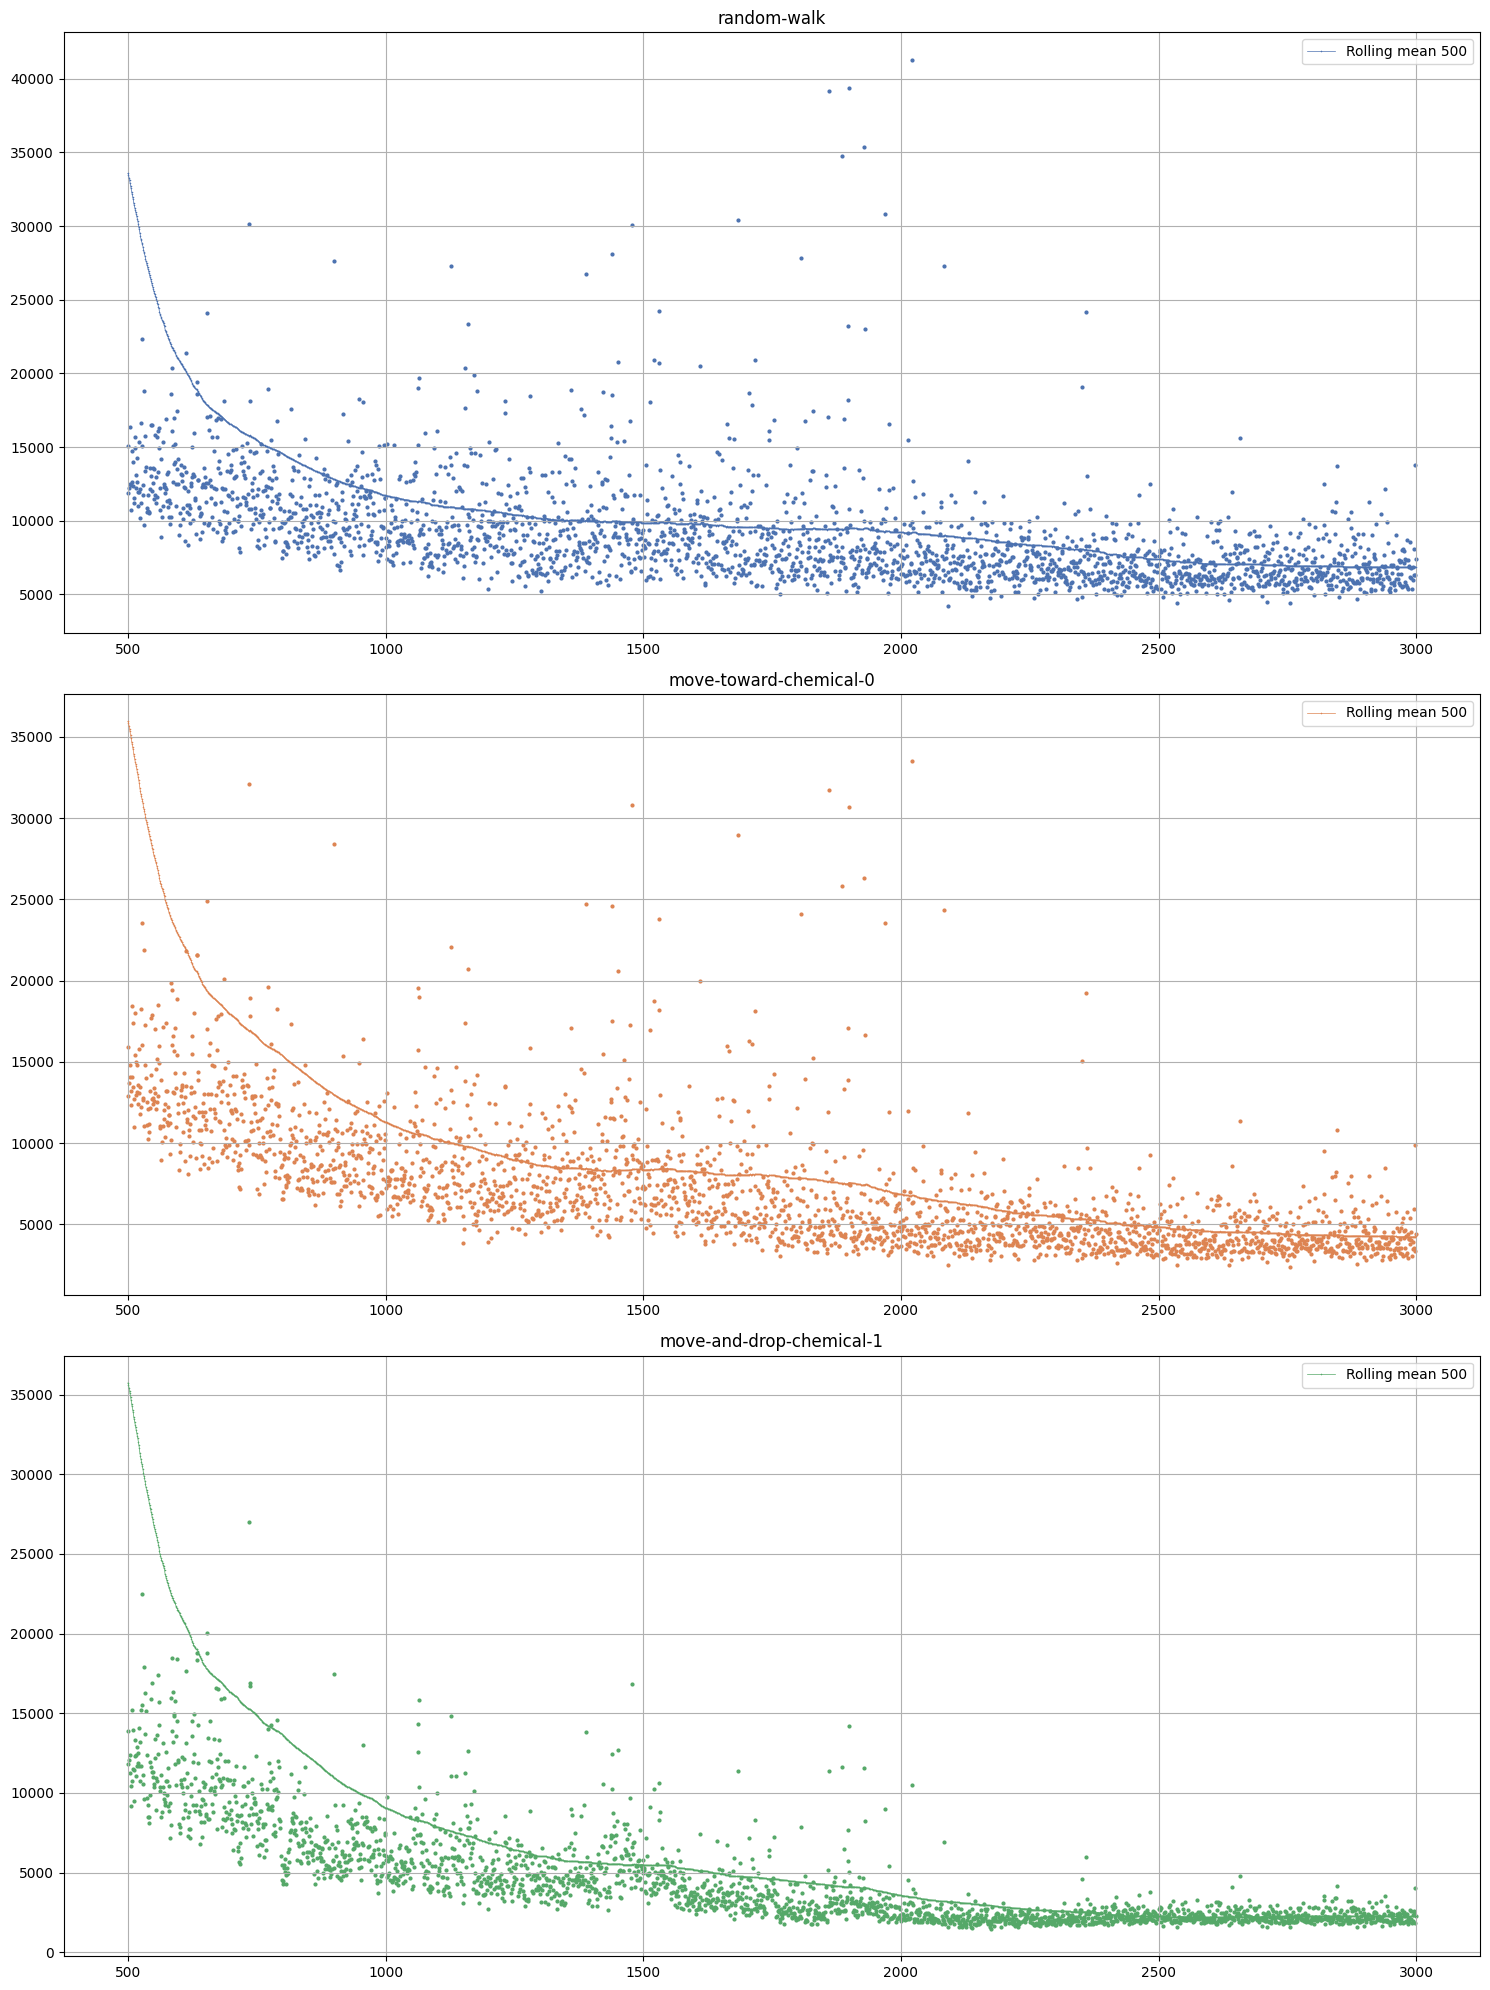

In [73]:
colors = ('#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#64B5CD', '#FFB000')
num_actions = 3
#num_actions = 4
#num_actions = 5
#num_actions = 6
#num_actions = 7
#fig, axs = plt.subplots(num_actions, 1, figsize=(15, 15))  # 1 riga, 2 colonne
x = [i for i in range(500, 3000)]
fig, axs = plt.subplots(num_actions, 1, figsize=(15, 20))  # 1 riga, 2 colonne
for i, ax in enumerate(axs):
    idx = i + 3
    y = results[results.columns[idx]].rolling(window=500).mean()
    #idx = i + 7
    ax.grid()
    ax.scatter(x, results[results.columns[idx]][500:], s=4, linewidth=1.0, color=colors[i])
    ax.plot(x, y[500:], label="Rolling mean 500", marker='x',
            markersize=.5, linewidth=.5, color=colors[i])
    #ax.plot(results.index, results[results.columns[idx]].rolling(window=100).mean(), label="Rolling mean 100",
    #        markersize=.5, linewidth=.5, color=colors[i])
    ax.set_title(results.columns[idx])
    ax.legend()
fig.tight_layout()
#plt.savefig("Cluster_avg_actions")
plt.show()

In [2]:
def compute_freqs_4(row, ag, col):
    tot = row[f"(cluster_learner {ag})-random-walk"] + row[f"(cluster_learner {ag})-move-toward-chemical"] + row[
        f"(cluster_learner {ag})-drop-chemical"] + row[f"(cluster_learner {ag})-move-away-chemical"]
    return row[col] * 100 / tot

def compute_mca_4(row, ag):
    return pd.to_numeric(
        row[[
            f"(cluster_learner {ag})-move-toward-chemical",
            f"(cluster_learner {ag})-random-walk",
            f"(cluster_learner {ag})-drop-chemical",
            f"(cluster_learner {ag})-move-away-chemical"
        ]]).idxmax().split(f"(cluster_learner {ag})-")[1]

def compute_freqs_3(row, ag, col):
    tot = row[f"(cluster_learner {ag})-random-walk"] + row[f"(cluster_learner {ag})-move-toward-chemical"] + row[f"(cluster_learner {ag})-drop-chemical"]
    return row[col] * 100 / tot

def compute_mca_3(row, ag):
    return pd.to_numeric(
        row[[
            f"(cluster_learner {ag})-move-toward-chemical",
            f"(cluster_learner {ag})-random-walk",
            f"(cluster_learner {ag})-drop-chemical",
        ]]).idxmax().split(f"(cluster_learner {ag})-")[1]

In [6]:
#df = results.copy()
#df = pd.read_csv("server_runs/runs/train/train_02_08_2025__11_36_45/iql_train_output_02_08_2025__11_36_45.csv")
df = pd.read_csv("server_runs/runs/train/train_02_16_2025__17_09_49/iql_train_output_02_16_2025__17_09_49.csv")

In [7]:
for agent in range(10):
    df[f"(cluster_learner {agent})-move-toward-chemical-%"] = df.apply(
        compute_freqs_4,
        args=(agent, f"(cluster_learner {agent})-move-toward-chemical"),
        axis=1
    )
    df[f"(cluster_learner {agent})-random-walk-%"] = df.apply(
        compute_freqs_4,
        args=(agent, f"(cluster_learner {agent})-random-walk"),
        axis=1
    )
    df[f"(cluster_learner {agent})-drop-chemical-%"] = df.apply(
        compute_freqs_4,
        args=(agent, f"(cluster_learner {agent})-drop-chemical"),
        axis=1
    )
    df[f"(cluster_learner {agent})-move-away-chemical-%"] = df.apply(
        compute_freqs_4,
        args=(agent, f"(cluster_learner {agent})-move-away-chemical"),
        axis=1
    )
for agent in range(10):
    df[f"(cluster_learner {agent}) MCA"] = df.apply(compute_mca_4, args=(agent,), axis=1)

In [37]:
for agent in range(20):
    df[f"(cluster_learner {agent})-move-toward-chemical-%"] = df.apply(
        compute_freqs_3,
        args=(agent, f"(cluster_learner {agent})-move-toward-chemical"),
        axis=1
    )
    df[f"(cluster_learner {agent})-random-walk-%"] = df.apply(
        compute_freqs_3,
        args=(agent, f"(cluster_learner {agent})-random-walk"),
        axis=1
    )
    df[f"(cluster_learner {agent})-drop-chemical-%"] = df.apply(
        compute_freqs_3,
        args=(agent, f"(cluster_learner {agent})-drop-chemical"),
        axis=1
    )
for agent in range(20):
    df[f"(cluster_learner {agent}) MCA"] = df.apply(compute_mca_3, args=(agent,), axis=1)

In [19]:
df.head()

,Episode,Tick,Avg cluster X episode,Cluster avg reward X episode,Cluster random-walk,Cluster drop-chemical,Cluster move-toward-chemical,Cluster move-away-chemical,(cluster_learner 0)-random-walk,(cluster_learner 0)-drop-chemical,...,(cluster_learner 10) MCA,(cluster_learner 11) MCA,(cluster_learner 12) MCA,(cluster_learner 13) MCA,(cluster_learner 14) MCA,(cluster_learner 15) MCA,(cluster_learner 16) MCA,(cluster_learner 17) MCA,(cluster_learner 18) MCA,(cluster_learner 19) MCA
0,1,500,1.23,3.1556,2520,2579,2433,2468,113,144,...,move-away-chemical,random-walk,random-walk,move-toward-chemical,move-away-chemical,drop-chemical,move-toward-chemical,random-walk,random-walk,move-away-chemical
1,2,1000,1.23,3.2109,2543,2503,2491,2463,149,129,...,random-walk,move-toward-chemical,move-away-chemical,drop-chemical,drop-chemical,move-away-chemical,move-toward-chemical,random-walk,drop-chemical,move-toward-chemical
2,3,1500,1.25,3.3395,2474,2475,2471,2580,116,117,...,move-away-chemical,random-walk,move-toward-chemical,move-toward-chemical,random-walk,drop-chemical,random-walk,random-walk,random-walk,move-away-chemical
3,4,2000,1.26,3.5156,2595,2478,2488,2439,121,118,...,move-away-chemical,move-toward-chemical,random-walk,drop-chemical,drop-chemical,move-away-chemical,move-away-chemical,random-walk,move-toward-chemical,random-walk
4,5,2500,1.23,3.1042,2397,2569,2477,2557,110,124,...,drop-chemical,drop-chemical,drop-chemical,drop-chemical,move-away-chemical,move-toward-chemical,move-away-chemical,move-toward-chemical,move-toward-chemical,random-walk


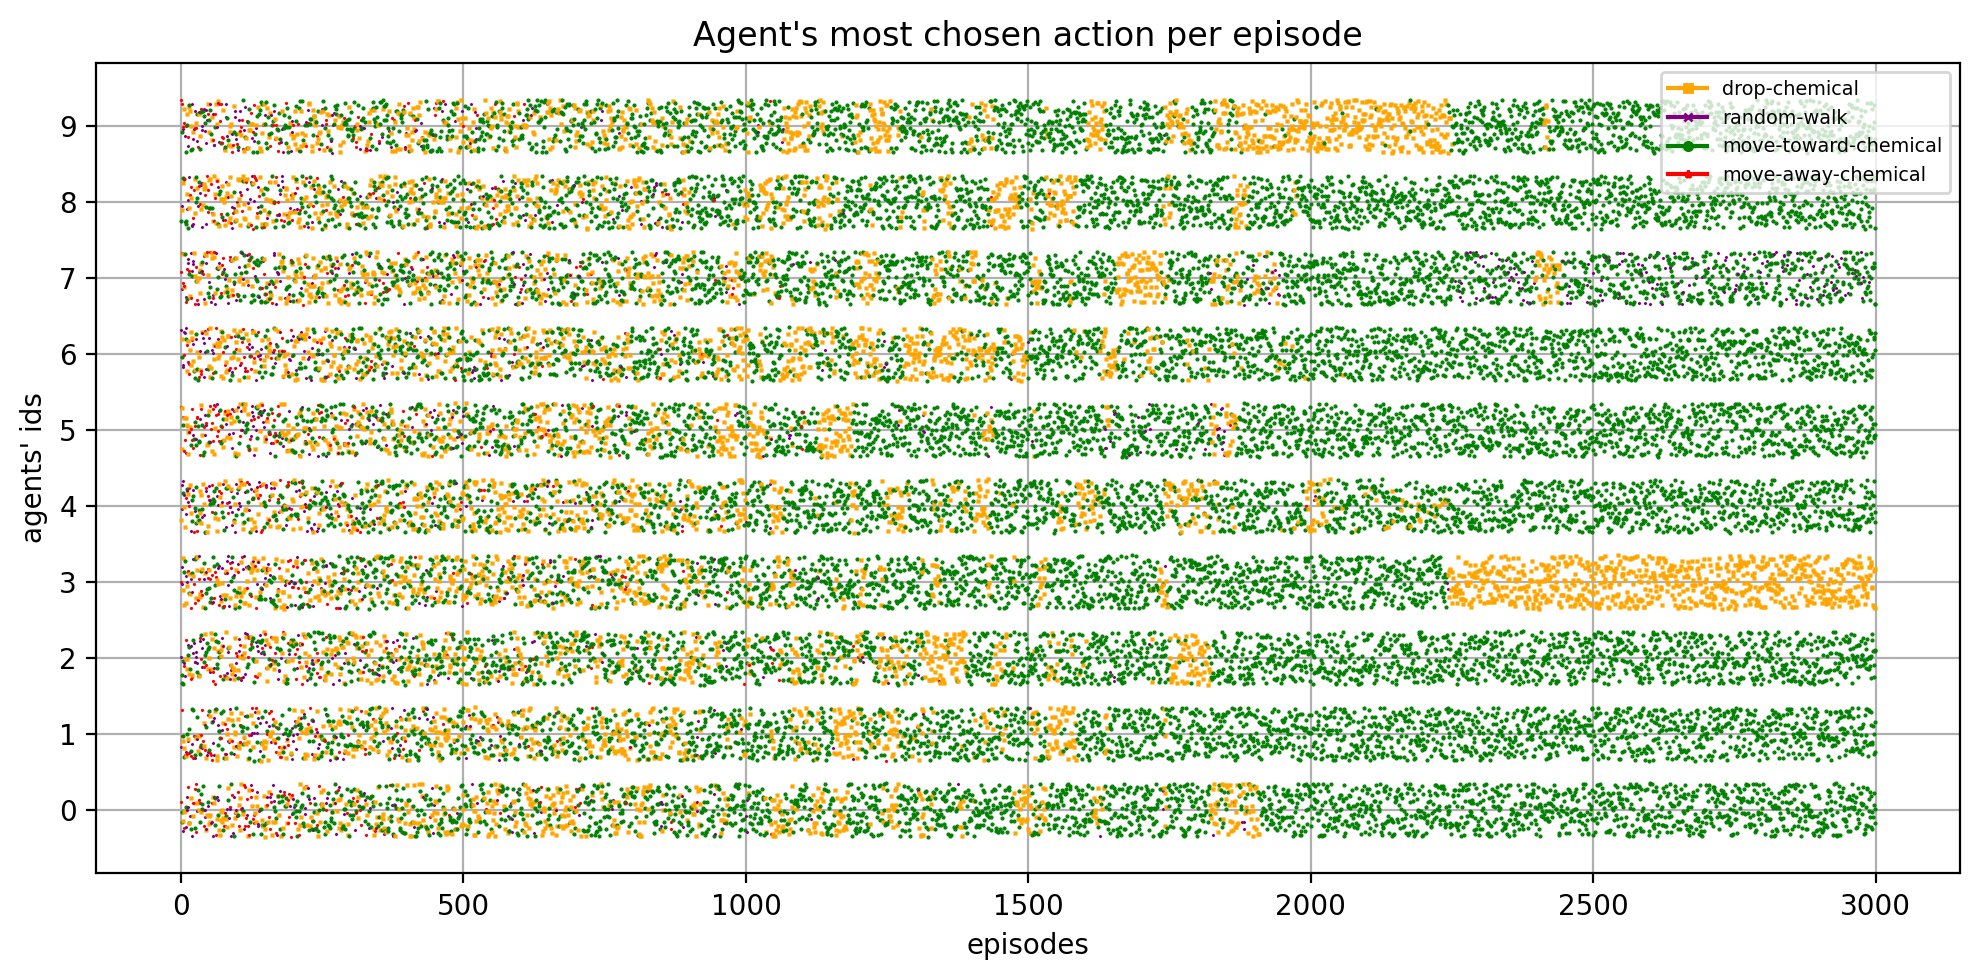

In [8]:
from matplotlib.lines import Line2D

marker_mca = {
    "drop-chemical": {
        'marker': 's',
        'color': 'orange'},
    "random-walk": {
        'marker': 'x',
        'color': 'purple'},
    "move-toward-chemical": {
        'marker': 'o',
        'color': 'green'},
    "move-away-chemical": {
        'marker': '*',
        'color': 'red'},
}
fig = plt.figure(figsize=(10, 5), dpi=200)
# ax = fig.add_subplot(projection='3d')
plt.grid()
plt.title(f"Agent's most chosen action per episode")
plt.ylabel(f"agents' ids")
plt.xlabel(f"episodes")

for row in df.index[:]:
    for agent in range(10):
        jitter = np.random.uniform(-0.35, 0.35)
        plt.plot(row, agent + jitter, marker=marker_mca[df.loc[row, f"(cluster_learner {agent}) MCA"]]['marker'],
                 markersize=0.5, color=marker_mca[df.loc[row, f"(cluster_learner {agent}) MCA"]]['color'])

custom_lines = [Line2D([], [], color='orange', marker="s"),
                Line2D([], [], color='purple', marker="x"),
                Line2D([], [], color='green', marker="o"),
                Line2D([], [], color='red', marker="*")] 

plt.yticks([i for i in range(10)])
plt.legend(custom_lines, ["drop-chemical", "random-walk", "move-toward-chemical", "move-away-chemical"], loc=1, fontsize="x-small", markerscale=0.5)
fig.tight_layout()
plt.show()

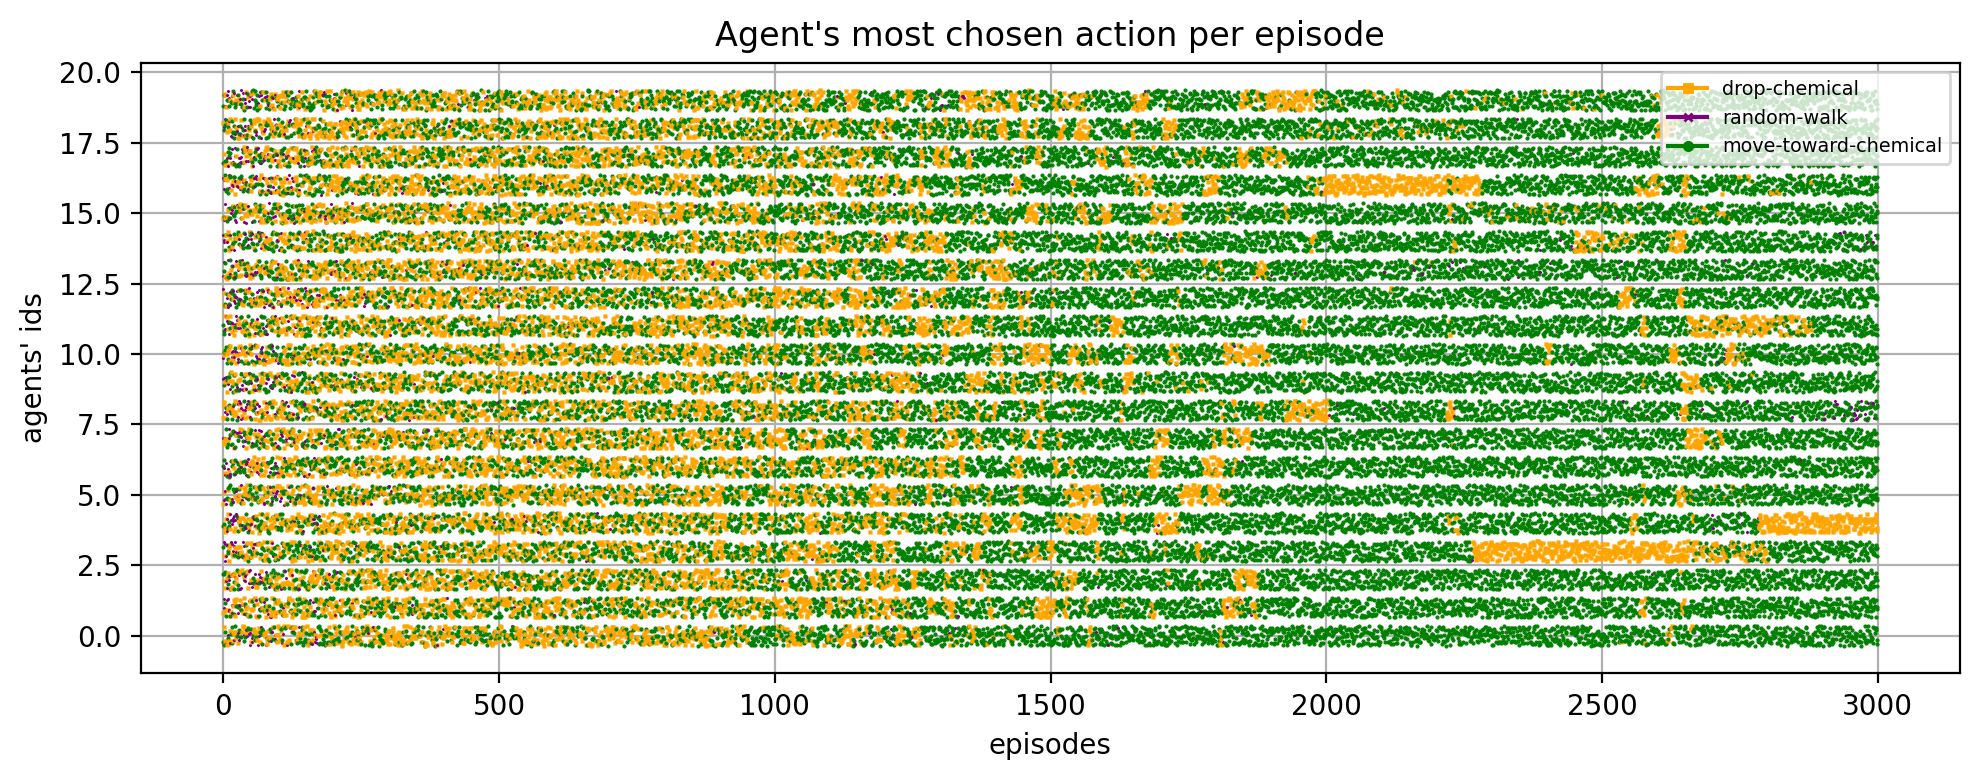

In [38]:
from matplotlib.lines import Line2D

marker_mca = {
    "drop-chemical": {
        'marker': 's',
        'color': 'orange'},
    "random-walk": {
        'marker': 'x',
        'color': 'purple'},
    "move-toward-chemical": {
        'marker': 'o',
        'color': 'green'},
}
fig = plt.figure(figsize=(10, 4), dpi=200)
# ax = fig.add_subplot(projection='3d')
plt.grid()
plt.title(f"Agent's most chosen action per episode")
plt.ylabel(f"agents' ids")
plt.xlabel(f"episodes")

for row in df.index[:]:
    for agent in range(20):
        jitter = np.random.uniform(-0.35, 0.35)
        plt.plot(row, agent + jitter, marker=marker_mca[df.loc[row, f"(cluster_learner {agent}) MCA"]]['marker'],
                 markersize=0.5, color=marker_mca[df.loc[row, f"(cluster_learner {agent}) MCA"]]['color'])

custom_lines = [Line2D([], [], color='orange', marker="s"),
                Line2D([], [], color='purple', marker="x"),
                Line2D([], [], color='green', marker="o")] 

plt.legend(custom_lines, ["drop-chemical", "random-walk", "move-toward-chemical"], loc=1, fontsize="x-small", markerscale=0.5)
fig.tight_layout()
plt.show()